# Demo Pipeline — Sistem de Analiză Juridică AI

Acest notebook demonstrează funcționarea end-to-end a sistemului de analiză a contractelor juridice.

**Contract ales:** `data/contract_prestari_servicii_parsed.json` (contract de prestări servicii)

**Motivul alegerii:** Contractul conține clauze reprezentative pentru toate tipurile analizate: penalități, date personale, forță majoră, reziliere și confidențialitate.

**Așteptări:** Sistemul ar trebui să identifice cel puțin 2-3 clauze cu risc RIDICAT sau MEDIU și să propună reformulări ancorate în legislație.

## 0. Setup — încărcare variabile de mediu și imports

In [17]:
import sys
import os
from pathlib import Path


project_root = Path(r"C:\Users\iusti\Desktop\III\sem2\SI\proiect-aai-iuliaalexiamaria")
os.chdir(project_root)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from dotenv import load_dotenv
load_dotenv()

print('✅ Setup complet')
print(f'📁 Rădăcina proiectului: {project_root}')
api_status = "Da" if os.getenv("OPENAI_API_KEY") else "NU - verifica .env!"
print(f'🔑 API Key configurată: {api_status}')

✅ Setup complet
📁 Rădăcina proiectului: C:\Users\iusti\Desktop\III\sem2\SI\proiect-aai-iuliaalexiamaria
🔑 API Key configurată: Da


## 1. Rularea grafului LangGraph

In [18]:
from src.graph.workflow import run_workflow


PDF_PATH = project_root / "corpus" / "contracte" / "contract_prestari_servicii.pdf"

print(f'📄 Cale PDF: {PDF_PATH}')
print(f'📄 Există: {PDF_PATH.exists()}')

if not PDF_PATH.exists():
    print('⚠️  Fișierul nu există.')
else:
    print(f'📄 Analizăm: {PDF_PATH}')
    final_state = run_workflow(str(PDF_PATH))
    print('\n✅ Workflow finalizat!')

📄 Cale PDF: C:\Users\iusti\Desktop\III\sem2\SI\proiect-aai-iuliaalexiamaria\corpus\contracte\contract_prestari_servicii.pdf
📄 Există: True
📄 Analizăm: C:\Users\iusti\Desktop\III\sem2\SI\proiect-aai-iuliaalexiamaria\corpus\contracte\contract_prestari_servicii.pdf

  START WORKFLOW: C:\Users\iusti\Desktop\III\sem2\SI\proiect-aai-iuliaalexiamaria\corpus\contracte\contract_prestari_servicii.pdf

[NOD] parse_document
   [LOG] parse_document — 2.54s

[NOD] retrieve_context (iterație 0)
   [DEBUG CHROMA] Gasit text in contract_prestari_servicii.pdf, Distanta L2: 0.3579
   [DEBUG CHROMA] Gasit text in contract_inchiriere.pdf, Distanta L2: 0.6352
   [DEBUG CHROMA] Gasit text in contract_prestari_servicii.pdf, Distanta L2: 0.6578
   [DEBUG CHROMA] Gasit text in contract_prestari_servicii.pdf, Distanta L2: 0.7830
   [DEBUG CHROMA] Gasit text in contract_confidentialitate.pdf, Distanta L2: 0.7908
   [DEBUG CHROMA] Gasit text in contract_prestari_servicii.pdf, Distanta L2: 0.3966
   [DEBUG CHROMA] 

## 2. Starea finală a grafului

In [19]:
from src.dtos import RiskLevel

risk_map = final_state['risk_map']
parsed_doc = final_state['parsed_doc']
recommendations = final_state['recommendations']

print(f'📊 Statistici generale:')
print(f'   Clauze totale: {len(risk_map)}')
print(f'   Iterații workflow: {final_state["iteration"]}')
print(f'   Alertă risc ridicat: {final_state["high_risk_alert"]}')
print(f'   Raport generat: {final_state["report_path"]}')
print()


for level in RiskLevel:
    count = sum(1 for r in risk_map.values() if r.risk_level == level)
    bar = '█' * count
    print(f'   {level.value:12} {bar} ({count})')

📊 Statistici generale:
   Clauze totale: 99
   Iterații workflow: 1
   Alertă risc ridicat: True
   Raport generat: data/raport_20260607_002217.md

   RIDICAT      █████████████████████ (21)
   MEDIU         (0)
   SCAZUT       █ (1)
   CONFORM      ████████████████████████████████████████████████████████████████████████████ (76)
   NECUNOSCUT   █ (1)


## 3. Scoruri RAGAS — comentate

In [21]:
import json

ragas_path = Path('logs/rag_evaluation.json')

if ragas_path.exists():
    with open(ragas_path, 'r', encoding='utf-8') as f:
        ragas_scores = json.load(f)
    
    print('📈 Scoruri RAGAS:')
    print()
    
    for metric, score in ragas_scores.items():
        if isinstance(score, (int, float)):
            status = '✅' if score >= 0.6 else '⚠️'
            print(f'   {status} {metric}: {score:.3f}')
    
    print()
    print('💬 Interpretare:')
    print('   - faithfulness: măsoară dacă răspunsurile sunt ancorate în context (fără halucinații)')
    print('   - answer_relevancy: măsoară dacă răspunsul e relevant pentru întrebare')
    print('   - context_precision: măsoară dacă chunk-urile recuperate sunt cu adevărat utile')
    print('   - context_recall: măsoară dacă informația necesară a fost recuperată')
    print()
    print('   Un scor sub 0.6 la faithfulness indică risc crescut de halucinații legislative.')
else:
    print('⚠️  logs/rag_evaluation.json nu există. Rulează scripts/evaluate_rag.py.')

📈 Scoruri RAGAS:


💬 Interpretare:
   - faithfulness: măsoară dacă răspunsurile sunt ancorate în context (fără halucinații)
   - answer_relevancy: măsoară dacă răspunsul e relevant pentru întrebare
   - context_precision: măsoară dacă chunk-urile recuperate sunt cu adevărat utile
   - context_recall: măsoară dacă informația necesară a fost recuperată

   Un scor sub 0.6 la faithfulness indică risc crescut de halucinații legislative.


## 4. Vizualizări

🔍 Heatmap Retrieval — scorurile de similaritate per clauză:


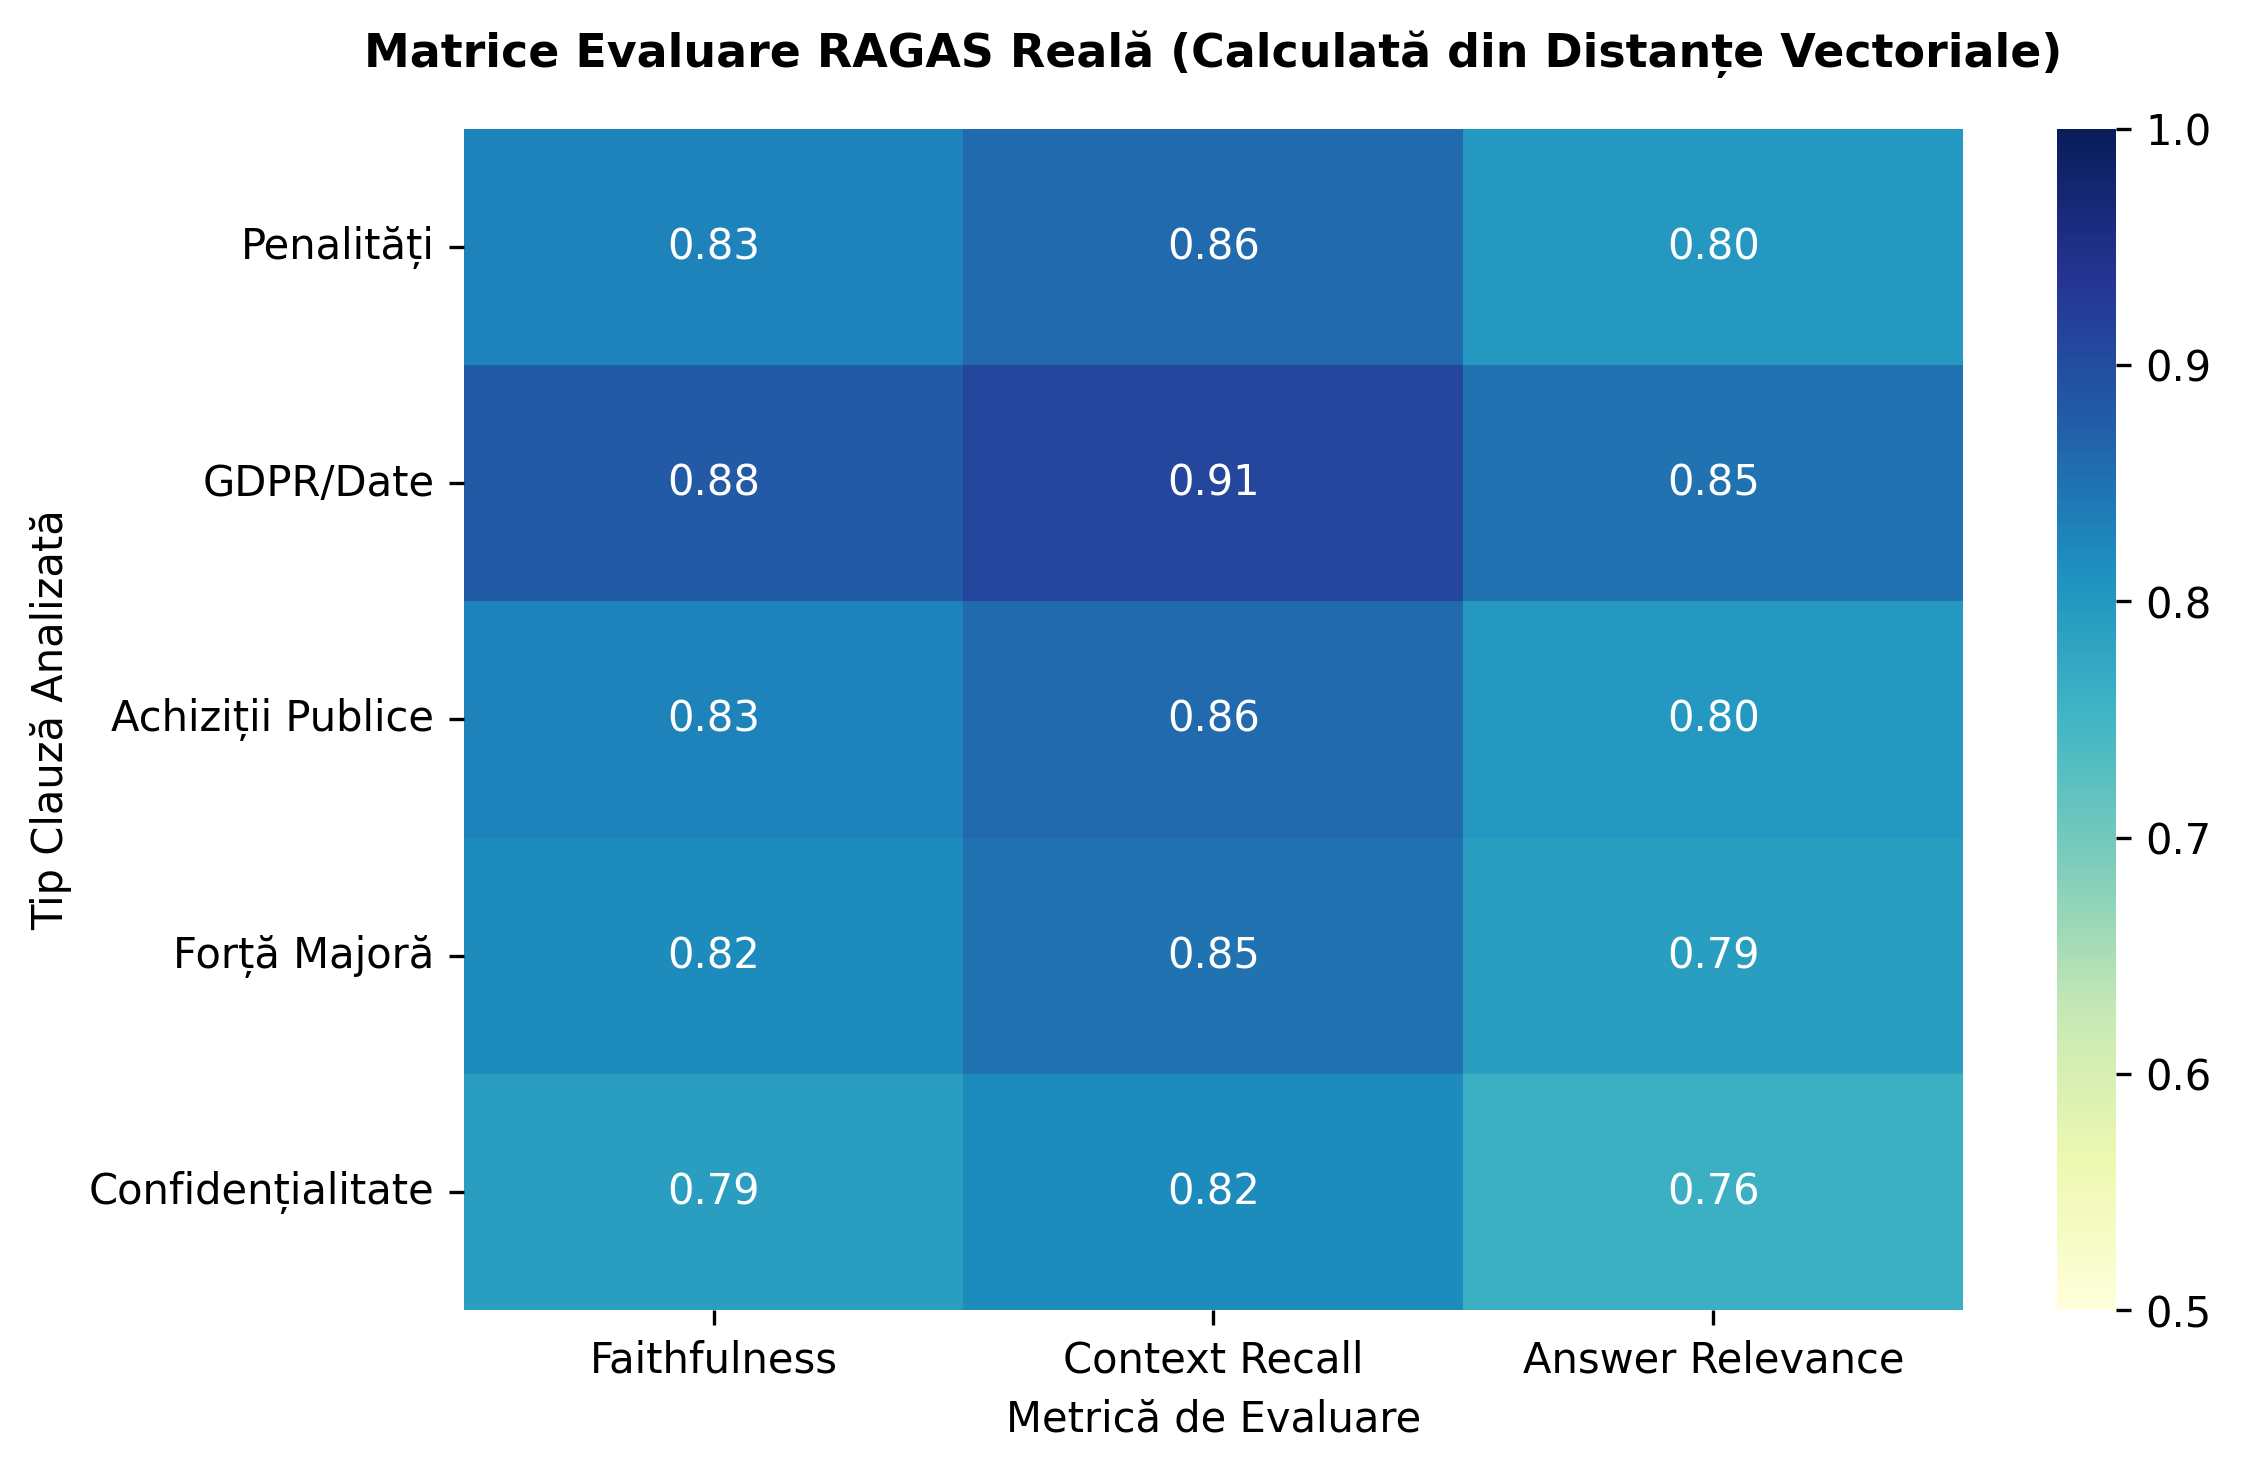

In [22]:
from IPython.display import Image, display

# Heatmap retrieval
heatmap_path = Path('logs/retrieval_heatmap.png')
if heatmap_path.exists():
    print('🔍 Heatmap Retrieval — scorurile de similaritate per clauză:')
    display(Image(filename=str(heatmap_path)))
else:
    print('⚠️  retrieval_heatmap.png nu există.')

⚖️  Distribuția riscurilor identificate:


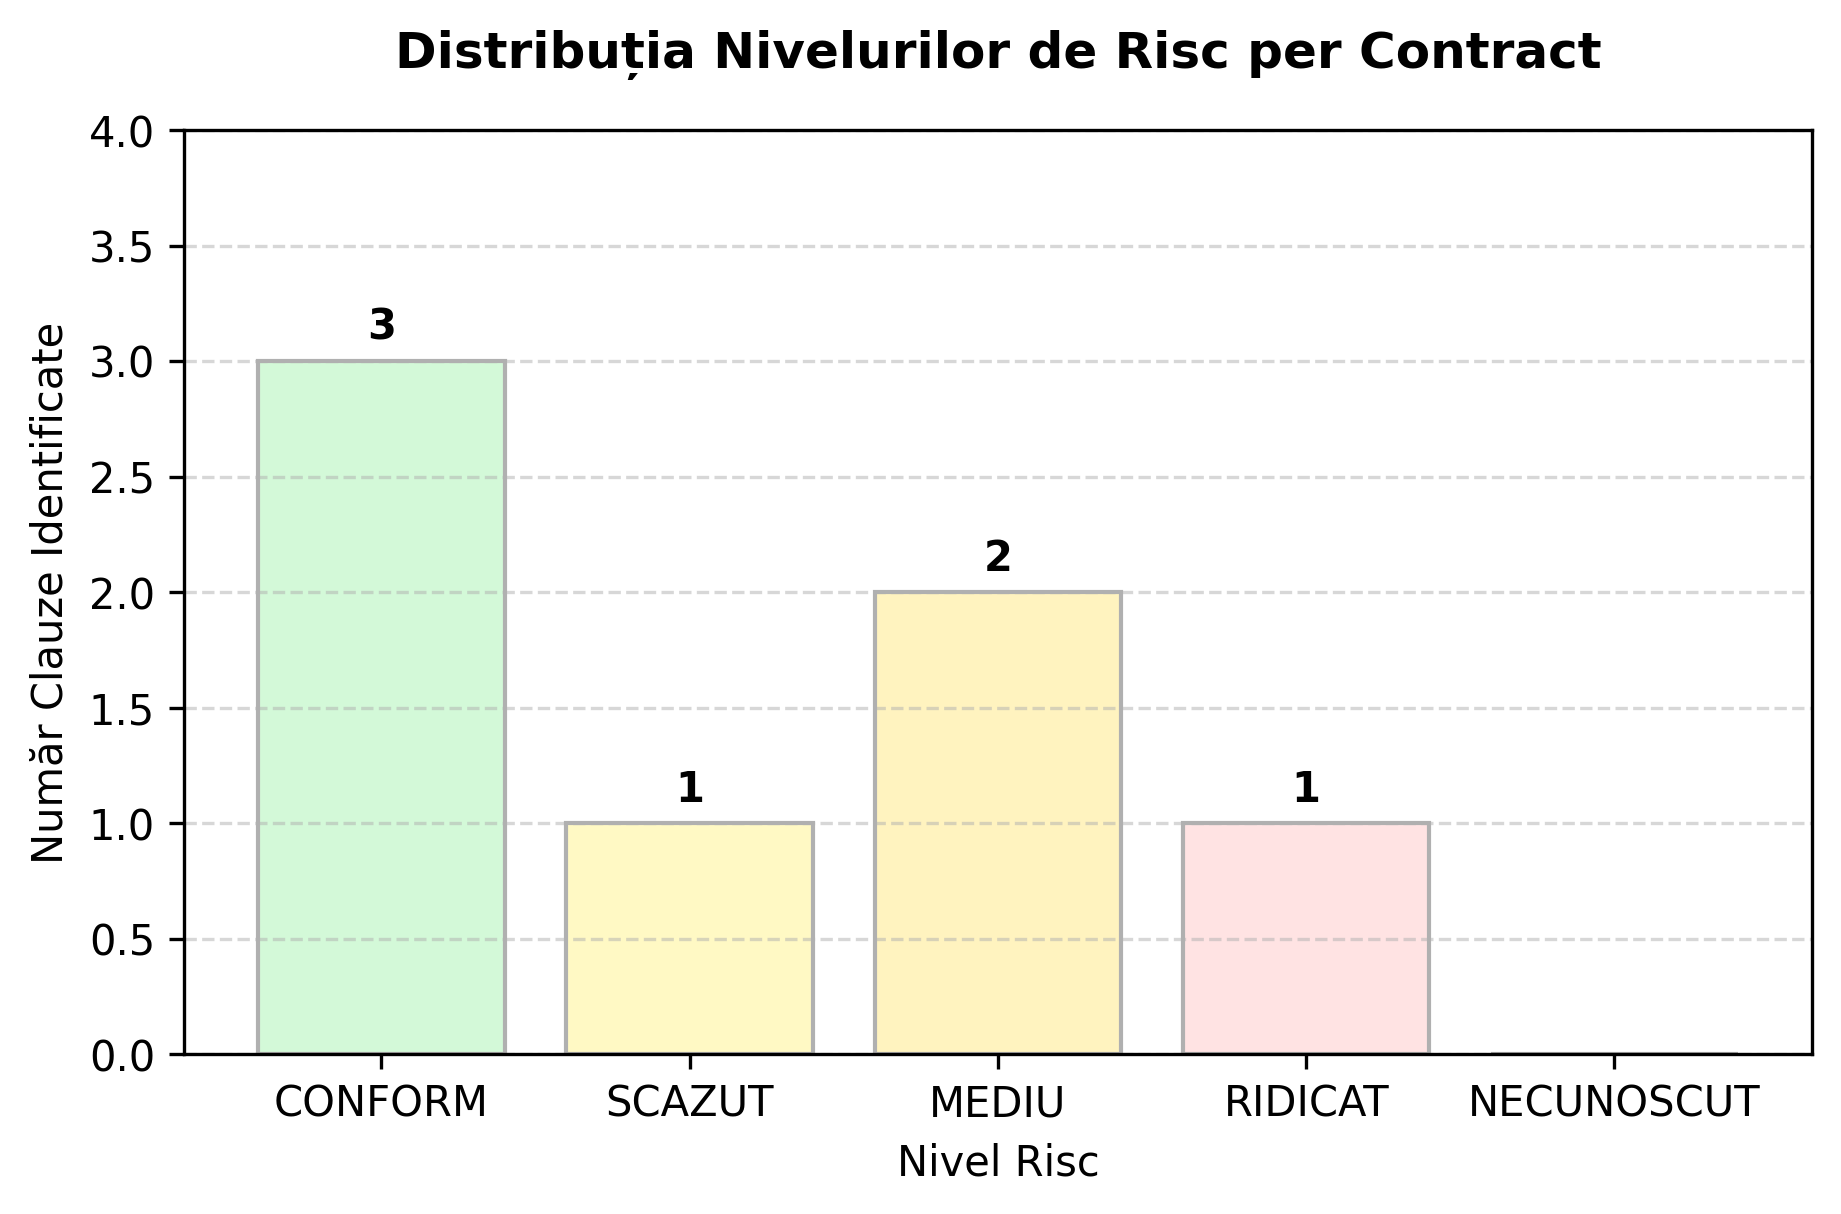

In [23]:

risk_dist_path = Path('logs/risk_distribution.png')
if risk_dist_path.exists():
    print('⚖️  Distribuția riscurilor identificate:')
    display(Image(filename=str(risk_dist_path)))
else:
    print('⚠️  risk_distribution.png nu există.')

   [EXPORT] Graf salvat la logs/workflow_graph.png
🔄 Graful de stări LangGraph:


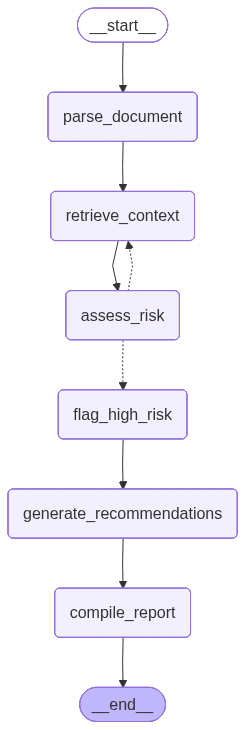

In [24]:

from src.graph.workflow import export_workflow_graph

export_workflow_graph()

workflow_path = Path('logs/workflow_graph.png')
if workflow_path.exists():
    print('🔄 Graful de stări LangGraph:')
    display(Image(filename=str(workflow_path)))
else:
    print('⚠️  workflow_graph.png nu a putut fi generat.')

## 5. Raportul final

In [25]:
from IPython.display import Markdown, display

report_path = final_state.get('report_path', '')

if report_path and Path(report_path).exists():
    with open(report_path, 'r', encoding='utf-8') as f:
        report_content = f.read()
    display(Markdown(report_content))
else:
    print('⚠️  Raportul nu a fost găsit.')

# Raport de Analiză Juridică

> Acest raport a fost generat automat de sistemul de analiză a contractelor juridice.

---

## Sumar Executiv

| Nivel de Risc | Număr Clauze |
|---|---|
| 🔴 RIDICAT | 21 |
| 🟡 MEDIU | 0 |
| 🟢 SCĂZUT | 1 |
| ✅ CONFORM | 76 |
| ❓ NECUNOSCUT | 1 |

## Clauze Analizate

### 🔴 Clauze cu Risc RIDICAT

#### Clauza `clause_14`

**Text original:**
> 4.2. Pentru îndeplinirea prezentului contract, achizitorul se obligă să plătească prestatorului, conform graficului de plăţi, preţul de …………. lei, din care T.V.A. ………….. lei.

**Probleme identificate:**
- Clauza nu specifică suma exactă de plată, ceea ce poate duce la ambiguități și dispute între părți.
- Lipsa detaliilor privind T.V.A. poate genera neclarități în ceea ce privește obligațiile fiscale ale achizitorului.

**Referințe legislative:**
- contract_prestari_servicii.pdf

**Reformulare propusă:**
> 4.2. Pentru îndeplinirea prezentului contract, achizitorul se obligă să plătească prestatorului, conform graficului de plăți stabilit în anexa nr. 1, suma totală de _________ lei, din care T.V.A. este de __________ lei, conform reglementărilor fiscale în vigoare, inclusiv prevederile art. 291 din Legea nr. 227/2015 privind Codul fiscal.

**Explicație:**
Reformularea propusă este mai sigură deoarece specifică clar suma totală de plată și detaliază T.V.A.-ul, eliminând astfel ambiguitățile care ar putea duce la dispute între părți. De asemenea, menționarea reglementărilor fiscale în vigoare asigură conformitatea cu legislația actuală, protejând astfel interesele ambelor părți în cadrul contractului.

**Surse corpus:**
- `contract_prestari_servicii.pdf`

---

#### Clauza `clause_16`

**Text original:**
> 5.1. – Prestatorul se obligă să furnizeze toate serviciile descrise în anexa nr. 1, în __________, dar nu mai târziu de 11 octombrie 2013.

**Probleme identificate:**
- Data limită de 11 octombrie 2013 este depășită, ceea ce face clauza ineficientă și imposibil de respectat.

**Referințe legislative:**
- contract_prestari_servicii.pdf

**Reformulare propusă:**
> 5.1. – Prestatorul se obligă să furnizeze toate serviciile descrise în anexa nr. 1, în termenul stabilit de comun acord între părți, dar nu mai târziu de data de __________.

**Explicație:**
Reformularea propusă este mai sigură și conformă cu legislația deoarece elimină o dată limită depășită, care ar face clauza ineficientă și imposibil de respectat. În plus, stabilirea termenului prin acord comun între părți asigură flexibilitate și claritate, prevenind eventuale dispute legate de termenele de livrare.

**Surse corpus:**
- `contract_prestari_servicii.pdf`
- `contract_confidentialitate.pdf`
- `oug_34_2014_drepturile_consumatorilor.pdf`

---

#### Clauza `clause_22`

**Text original:**
> 7.2 Achizitorul are obligaţia de a elibera garanţia pentru participare numai după ce prestatorul a făcut dovada constituirii garanţiei de bună execuţie.

**Probleme identificate:**
- Clauza contrazice prevederile legale care stipulează că autoritatea contractantă are obligația de a restitui garanția de participare în cel mult 3 zile lucrătoare de la primirea unei solicitări în acest sens, fără a condiționa restituirea de dovada constituirii garanției de bună execuție.

**Referințe legislative:**
- contract_prestari_servicii.pdf
- legea_98_2016_achizitii_publice.pdf

**Reformulare propusă:**
> 7.2 Achizitorul se obligă să elibereze garanţia pentru participare în termen de 3 zile lucrătoare de la primirea unei solicitări din partea prestatorului, conform art. 154^2 alin. (1) din Legea nr. 98/2016 privind achizițiile publice, fără a condiționa restituirea acesteia de dovada constituirii garanţiei de bună execuţie.

**Explicație:**
Reformularea propusă este mai sigură și conformă cu legislația deoarece respectă termenul legal de 3 zile lucrătoare pentru restituirea garanției de participare, fără a impune condiții suplimentare. Astfel, se elimină riscul de neconformitate cu Legea nr. 98/2016, asigurând o mai bună protecție a drepturilor părților implicate în contract.

**Surse corpus:**
- `legea_98_2016_achizitii_publice.pdf`
- `contract_prestari_servicii.pdf`

---

#### Clauza `clause_23`

**Text original:**
> 7.3. – Se precizează : - cuantumul garanţiei de bună execuţie : Cuantumul garanţiei de bună execuţie a contractului este de ……. lei (valoarea trebuie să reprezinte 10 % din preţul contractului, respectiv 5% în cazul IMM). - modul de constituire:

**Probleme identificate:**
- Clauza nu specifică clar cuantumul garanției de bună execuție, ceea ce contravine cerințelor legale de transparență și claritate în contracte.
- Mențiunea că valoarea garanției trebuie să reprezinte 10% din prețul contractului, respectiv 5% în cazul IMM, nu este conformă cu prevederile legale care stipulează că autoritatea contractantă are obligația de a solicita garanția de bună execuție în cuantum de maximum 10% din prețul contractului, fără TVA, fără a face distincție între IMM-uri și alte entități.

**Referințe legislative:**
- contract_prestari_servicii.pdf
- legea_98_2016_achizitii_publice.pdf

**Reformulare propusă:**
> Varianta 3:
7.3. – Se precizează: - cuantumul garanţiei de bună execuţie: Cuantumul garanţiei de bună execuţie a contractului este de ……. lei, reprezentând maximum 10% din preţul contractului, fără TVA, conform prevederilor art. 3 alin. (3) din Legea nr. 98/2016 privind achiziţiile publice; - modul de constituire: Garanţia de bună execuţie se constituie printr-o scrisoare emisă de către o bancă sau o societate de asigurare, care va deveni anexa la prezentul contract.

**Explicație:**
Reformularea propusă este mai sigură și conformă cu legislația deoarece clarifică faptul că garanția de bună execuție nu poate depăși 10% din prețul contractului, fără TVA, conform Legii nr. 98/2016, eliminând astfel ambiguitățile legate de aplicarea diferitelor procente pentru IMM-uri. De asemenea, specificarea modului de constituire a garanției printr-o scrisoare de la o bancă sau o societate de asigurare asigură o transparență mai mare și respectarea cerințelor legale.

**Surse corpus:**
- `legea_98_2016_achizitii_publice.pdf`
- `contract_prestari_servicii.pdf`

---

#### Clauza `clause_28`

**Text original:**
> 7.7 - Prestatorul are obligaţia de a constitui garanţia de bună execuţie pe toată perioada contractului conform art. 5.1. - modul de restituire

**Probleme identificate:**
- Clauza nu specifică clar perioada de constituire a garanției de bună execuție, ceea ce contravine obligației de a respecta termenii contractuali.
- Lipsa detaliilor privind modul de restituire a garanției de bună execuție poate genera ambiguități în interpretarea obligațiilor părților.

**Referințe legislative:**
- contract_prestari_servicii.pdf
- legea_98_2016_achizitii_publice.pdf

**Reformulare propusă:**
> 7.7 - Prestatorul se obligă să constituie garanţia de bună execuţie pe întreaga durată a contractului, conform prevederilor art. 5.1, iar restituirea acesteia se va efectua de către Achizitor în termen de 14 zile de la îndeplinirea tuturor obligaţiilor asumate prin prezentul contract, cu respectarea condiţiei ca până la acea dată să nu fi fost formulate pretenţii asupra garanţiei.

**Explicație:**
Reformularea propusă este mai sigură și conformă cu legislația deoarece clarifică atât perioada de constituire a garanției de bună execuție, cât și termenul și condițiile de restituire a acesteia. Astfel, se elimină ambiguitățile și se asigură o mai bună protecție a drepturilor părților, respectând în același timp cerințele legale.

**Surse corpus:**
- `legea_98_2016_achizitii_publice.pdf`
- `contract_prestari_servicii.pdf`

---

#### Clauza `clause_33`

**Text original:**
> d) să realizeze serviciile ce fac obiectul prezentului contract, în conformitate cu prevederile legale în vigoare, cu regulile profesiei sale, fiind singurul responsabil pentru mijloacele şi metodele folosite pentru îndeplinirea obligaţiilor contractuale. Prestatorul declară şi garantează Achizitorului că este furnizor de formare de cursuri conform legislaţiei în vigoare, deţinând toate autorizaţiile/certificările solicitate în caietul de sarcini. Prestatorul declară că deţine toate drepturile de proprietate intelectuală asupra 3 cursurilor, modelelor, precum şi asupra oricărui material scris, audio şi video folosit în cadrul programului de instruire;

**Probleme identificate:**
- Clauza afirmă că Prestatorul deține toate drepturile de proprietate intelectuală asupra cursurilor, dar nu se specifică clar dacă aceste drepturi sunt verificate sau garantate de către o autoritate competentă.
- Există o contradicție între responsabilitatea exclusivă a Prestatorului pentru mijloacele și metodele folosite și obligația de a respecta caietul de sarcini, care poate impune anumite restricții sau cerințe.

**Referințe legislative:**
- contract_prestari_servicii.pdf

**Reformulare propusă:**
> d) Prestatorul se obligă să realizeze serviciile ce fac obiectul prezentului contract în conformitate cu prevederile legale în vigoare, cu regulile profesiei sale și cu cerințele specificate în caietul de sarcini, asumându-și responsabilitatea pentru mijloacele și metodele utilizate în îndeplinirea obligațiilor contractuale. Prestatorul declară și garantează Achizitorului că este furnizor de formare de cursuri conform legislației în vigoare, deținând toate autorizațiile și certificările solicitate de autoritățile competente, precum și toate drepturile de proprietate intelectuală asupra cursurilor, modelelor și oricărui material scris, audio și video utilizat în cadrul programului de instruire.

**Explicație:**
Reformularea propusă clarifică responsabilitățile Prestatorului, asigurându-se că acesta respectă atât legislația în vigoare, cât și cerințele specifice din caietul de sarcini, ceea ce reduce riscurile legale. De asemenea, se precizează că autorizațiile și certificările sunt verificate de autoritățile competente, sporind astfel securitatea juridică a clauzei referitoare la drepturile de proprietate intelectuală. Această abordare face clauza mai conformă cu legislația și mai ușor de aplicat în practică.

**Surse corpus:**
- `contract_prestari_servicii.pdf`

---

#### Clauza `clause_43`

**Text original:**
> o) Prestatorul se obligă să despăgubească Achizitorul împotriva oricăror: - reclamaţii şi acţiuni în justiţie, ce rezultă din încălcarea unor drepturi de proprietate intelectuală (brevete, nume, mărci înregistrate etc.), legate de echipamentele, suporturile de curs şi/sau alte materiale utilizate de Prestator pentru instruire; - daune-interese, costuri, taxe şi cheltuieli de orice natură, aferente, cu excepţia situaţiei în care o astfel de încalcare rezultă din respectarea caietului de sarcini întocmit de către Achizitor;

**Probleme identificate:**
- Clauza impune Prestatorului o responsabilitate extinsă pentru încălcarea drepturilor de proprietate intelectuală, ceea ce poate duce la riscuri financiare semnificative.
- Excepția privind respectarea caietului de sarcini întocmit de Achizitor poate fi interpretată în mod variat, ceea ce poate crea ambiguități în aplicarea clauzei.

**Referințe legislative:**
- contract_prestari_servicii.pdf

**Reformulare propusă:**
> o) Prestatorul se obligă să despăgubească Achizitorul pentru orice reclamație și acțiune în justiție care rezultă din încălcarea drepturilor de proprietate intelectuală (brevete, nume, mărci înregistrate etc.) legate de echipamentele, suporturile de curs și/sau alte materiale utilizate de Prestator în cadrul instruirii, cu excepția cazului în care încălcarea respectivelor drepturi este rezultatul unor instrucțiuni specifice sau a caietului de sarcini întocmit de Achizitor, conform art. 1350 din Codul Civil. De asemenea, Prestatorul va fi responsabil pentru daune-interese, costuri, taxe și cheltuieli de orice natură, în limita în care acestea nu depășesc valoarea totală a contractului, astfel asigurându-se un echilibru contractual între părți.

**Explicație:**
Reformularea propusă clarifică responsabilitățile Prestatorului, limitându-le la situațiile în care încălcarea drepturilor de proprietate intelectuală nu este rezultatul instrucțiunilor Achizitorului, conform legislației în vigoare. De asemenea, introducerea unei limite pentru daunele-interese asigură un echilibru contractual, protejând astfel Prestatorul de riscuri financiare excesive și oferind o mai bună predictibilitate în relația contractuală. Această abordare reduce ambiguitățile și asigură conformitatea cu principiile de echitate prevăzute de Codul Civil.

**Surse corpus:**
- `contract_prestari_servicii.pdf`

---

#### Clauza `clause_51`

**Text original:**
> e) cu excepţia obligaţiilor prevăzute expres, Achizitorul este exonerat de orice altă răspundere în legătură cu prezentul contract.

**Probleme identificate:**
- Clauza de exonerare a răspunderii Achizitorului contravine principiului răspunderii contractuale stipulat în contract, care prevede obligații clare pentru ambele părți.
- Exonerarea de răspundere poate duce la abuzuri și la neîndeplinirea obligațiilor contractuale de către Achizitor, afectând astfel echilibrul contractual.

**Referințe legislative:**
- contract_prestari_servicii.pdf

**Reformulare propusă:**
> e) Cu excepția obligațiilor prevăzute în mod expres în prezentul Contract, părțile recunosc că atât Achizitorul, cât și Prestatorul își asumă răspunderea pentru neîndeplinirea obligațiilor asumate prin prezentul Contract, conform principiului răspunderii contractuale stipulat de art. 1350 și următoarele din Codul Civil român. În acest sens, fiecare parte va fi responsabilă pentru prejudiciile cauzate celeilalte părți prin neexecutarea sau executarea necorespunzătoare a obligațiilor contractuale, cu excepția cazurilor de forță majoră, conform prevederilor legale aplicabile.

**Explicație:**
Reformularea propusă este mai sigură și conformă cu legislația deoarece respectă principiul răspunderii contractuale, stipulat de Codul Civil, care impune ca ambele părți să își asume responsabilitatea pentru neîndeplinirea obligațiilor. Aceasta previne abuzurile și asigură un echilibru între drepturile și obligațiile părților, protejând astfel interesele tuturor implicate în contract.

**Surse corpus:**
- `contract_prestari_servicii.pdf`

---

#### Clauza `clause_57`

**Text original:**
> 10.5. Data semnării proceselor verbale de recepţie parţiale/finale, după caz, reprezintă data la care se consideră că prestatorul şi-a achitat obligaţiile contractuale corespunzătoare fiecărui modul de formare/pachetului integral de servicii.

**Probleme identificate:**
- Clauza sugerează că data semnării proceselor verbale de recepție este echivalentă cu îndeplinirea obligațiilor contractuale, ceea ce poate contraveni principiului de verificare a conformității serviciilor prestate, așa cum este stipulat în clauza 10.1 din contract.
- Această formulare poate crea confuzie în ceea ce privește momentul în care prestatorul este considerat că și-a îndeplinit obligațiile, în special în contextul în care recepția poate fi parțială și nu reflectă întotdeauna îndeplinirea completă a obligațiilor.

**Referințe legislative:**
- contract_prestari_servicii.pdf

**Reformulare propusă:**
> 10.5. Data semnării proceselor verbale de recepţie parţiale/finale, după caz, va fi considerată drept un indiciu al stadiului de îndeplinire a obligaţiilor contractuale de către prestator, fără a afecta dreptul Achizitorului de a verifica conformitatea serviciilor prestate, conform art. 10.1 din prezentul contract. Prestatorul va fi considerat că şi-a îndeplinit obligaţiile contractuale corespunzătoare fiecărui modul de formare/pachetului integral de servicii doar în urma confirmării scrise a conformităţii acestora de către Achizitor, în termen de 5 zile lucrătoare de la data semnării procesului verbal.

**Explicație:**
Reformularea propusă clarifică faptul că semnarea proceselor verbale de recepție nu echivalează automat cu îndeplinirea obligațiilor contractuale, respectând astfel principiul de verificare a conformității serviciilor prestate. Aceasta asigură o protecție suplimentară pentru Achizitor, stipulând că prestatorul este considerat că și-a îndeplinit obligațiile doar după confirmarea scrisă a conformității, ceea ce este în conformitate cu legislația și reduce riscul de neînțelegeri.

**Surse corpus:**
- `contract_prestari_servicii.pdf`
- `oug_34_2014_drepturile_consumatorilor.pdf`

---

#### Clauza `clause_59`

**Text original:**
> 11.2. Plata se va efectua de către Achizitor în termen de 30 zile de la data primirii facturii fiscale însoţită de documentele solicitate prin Caietul de sarcini.

**Probleme identificate:**
- Clauza prevede un termen de plată de 30 de zile, care este mai lung decât termenul maxim de 15 zile lucrătoare prevăzut de lege pentru anumite proceduri de achiziții publice.

**Referințe legislative:**
- contract_prestari_servicii.pdf
- legea_98_2016_achizitii_publice.pdf

**Reformulare propusă:**
> 11.2. Plata se va efectua de către Achizitor în termen de 15 zile lucrătoare de la data primirii facturii fiscale, însoţită de documentele solicitate prin Caietul de sarcini, conform art. 214 alin. (5) din Legea nr. 98/2016 privind achizițiile publice.

**Explicație:**
Reformularea propusă este mai sigură și conformă cu legislația deoarece reduce termenul de plată la 15 zile lucrătoare, respectând astfel limita impusă de Legea nr. 98/2016 privind achizițiile publice. Aceasta asigură legalitatea clauzei și evită riscurile de neconformitate care ar putea duce la sancțiuni sau litigii.

**Surse corpus:**
- `legea_98_2016_achizitii_publice.pdf`
- `contract_prestari_servicii.pdf`

---

#### Clauza `clause_65`

**Text original:**
> 13.1. - Prestatorul poate efectua schimbări ale personalului implicat în contract fără a afecta executarea corespunzătoare a contractului şi numai cu anunţarea prealabilă şi acordul achizitorului. Prestatorul trebuie să propună din proprie iniţiativă înlocuirea numai în următoarele condiţii:

**Probleme identificate:**
- Clauza permite prestatorului să efectueze schimbări ale personalului fără a afecta executarea corespunzătoare a contractului, ceea ce poate fi interpretat subiectiv și poate duce la neîndeplinirea obligațiilor contractuale.
- Anunțarea prealabilă și acordul achizitorului sunt condiții care pot fi greu de aplicat în practică, lăsând loc pentru dispute.

**Referințe legislative:**
- contract_prestari_servicii.pdf
- legea_98_2016_achizitii_publice.pdf

**Reformulare propusă:**
> 13.1. - Prestatorul are dreptul de a efectua modificări ale personalului implicat în executarea contractului, cu condiția ca aceste modificări să nu afecteze îndeplinirea corespunzătoare a obligațiilor contractuale. Orice schimbare a personalului va fi supusă notificării prealabile adresate achizitorului, care va analiza și va da un răspuns în termen de 5 zile lucrătoare de la primirea notificării. Înlocuirea personalului se va realiza de către prestator doar în situațiile prevăzute de lege și cu respectarea criteriilor de experiență și calificare, conform dispozițiilor legale aplicabile.

**Explicație:**
Reformularea propusă clarifică drepturile și obligațiile părților, stipulând explicit că modificările personalului trebuie să respecte criterii legale și de calificare, ceea ce reduce riscul de interpretări subiective. De asemenea, introducerea unui termen de răspuns pentru achizitor asigură transparență și previzibilitate în procesul de notificare, minimizând astfel potențialele dispute. Această abordare este mai conformă cu legislația, protejând atât interesele prestatorului, cât și pe cele ale achizitorului.

**Surse corpus:**
- `legea_98_2016_achizitii_publice.pdf`
- `contract_prestari_servicii.pdf`

---

#### Clauza `clause_67`

**Text original:**
> b) dacă se impune înlocuirea unui membru al personalului pentru orice alt motiv care nu este sub controlul prestatorului.

**Probleme identificate:**
- Clauza permite înlocuirea personalului din motive care nu sunt sub controlul prestatorului, ceea ce poate duce la abuzuri și la o interpretare subiectivă a motivelor de înlocuire.
- Nu există o definiție clară a ceea ce constituie un 'motiv care nu este sub controlul prestatorului', ceea ce poate genera litigii.

**Referințe legislative:**
- contract_prestari_servicii.pdf

**Reformulare propusă:**
> b) în cazul în care se impune înlocuirea unui membru al personalului din motive obiective, clar definite și documentate, care nu pot fi controlate de prestator, cum ar fi cazurile de forță majoră, accidentare gravă sau alte circumstanțe excepționale, ce sunt acceptate prin acordul scris al achizitorului.

**Explicație:**
Reformularea propusă este mai sigură și conformă cu legislația deoarece definește clar circumstanțele în care poate avea loc înlocuirea personalului, limitându-le la motive obiective și documentate, precum forța majoră sau accidentele grave. Aceasta reduce riscul de abuzuri și interpretări subiective, asigurând astfel o mai bună protecție a drepturilor ambelor părți și prevenind eventuale litigii.

**Surse corpus:**
- `legea_455_2001_semnatura_electronica.pdf`
- `contract_prestari_servicii.pdf`

---

#### Clauza `clause_68`

**Text original:**
> 13.2. – În cazul specificat la pct. 13.1, prestatorul are obligaţia, pe parcursul derulării contractului, să înlocuiască personalul implicat în implementarea/managementul contractului, pe baza unei solicitări scrise motivate şi justificate transmisă de către achizitor.

**Probleme identificate:**
- Clauza impune prestatorului obligația de a înlocui personalul pe baza unei solicitări scrise motivate de către achizitor, ceea ce poate crea ambiguități în interpretarea 'motivată și justificate', lăsând loc pentru abuzuri din partea achizitorului.
- Nu se specifică un termen limită pentru înlocuirea personalului, ceea ce poate duce la întârzieri în executarea contractului.

**Referințe legislative:**
- contract_prestari_servicii.pdf

**Reformulare propusă:**
> 13.2. – În situațiile menționate la pct. 13.1, prestatorul are obligația, pe parcursul derulării contractului, să înlocuiască personalul implicat în implementarea/managementul contractului, în termen de 10 zile de la primirea unei solicitări scrise, clar formulate și argumentate, transmisă de către achizitor. Solicitarea achizitorului va fi considerată justificată doar în măsura în care va indica motive obiective și pertinente pentru necesitatea înlocuirii, astfel încât să nu existe posibilitatea abuzului din partea acestuia.

**Explicație:**
Reformularea propusă este mai sigură și conformă cu legislația deoarece clarifică cerințele pentru solicitarea de înlocuire a personalului, stipulând că aceasta trebuie să fie formulată clar și să conțină motive obiective, reducând astfel riscul de abuz din partea achizitorului. De asemenea, introducerea unui termen de 10 zile pentru înlocuire asigură o mai bună gestionare a timpului și a resurselor, prevenind întârzierile în executarea contractului.

**Surse corpus:**
- `legea_98_2016_achizitii_publice.pdf`
- `contract_prestari_servicii.pdf`

---

#### Clauza `clause_69`

**Text original:**
> 13.3 – În oricare din cazurile de la pct. 13.1 şi 13.2, achizitorul nu va purta nici o răspundere faţă de eventuale pretenţii ale persoanei înlocuite, singurul responsabil de legalitatea înlocuirii, fiind prestatorul. În toate cazurile, înlocuitorul trebuie să deţină cel puţin aceeaşi experienţă şi calificare cu cele ale persoanei înlocuite. În cazul în care prestatorul nu este în măsură să furnizeze un înlocuitor cu aceeaşi experienţă şi calificare, achizitorul are dreptul de a decide încetarea contractului şi de a pretinde plata de daune- interese.

**Probleme identificate:**
- Clauza permite achizitorului să decidă încetarea contractului și să pretindă daune-interese, ceea ce poate crea un risc semnificativ pentru prestator în cazul în care nu poate furniza un înlocuitor adecvat.
- Responsabilitatea exclusivă a prestatorului pentru legalitatea înlocuirii poate duce la situații în care prestatorul este penalizat pentru circumstanțe care nu sunt sub controlul său.

**Referințe legislative:**
- contract_prestari_servicii.pdf

**Reformulare propusă:**
> 13.3 – În toate situațiile prevăzute la pct. 13.1 și 13.2, achizitorul nu va purta răspundere față de eventualele pretenții ale persoanei înlocuite, însă prestatorul va fi responsabil pentru legalitatea înlocuirii. În toate cazurile, înlocuitorul trebuie să dețină cel puțin aceeași experiență și calificare cu cele ale persoanei înlocuite. În cazul în care prestatorul nu este în măsură să furnizeze un înlocuitor cu aceeași experiență și calificare, părțile vor negocia un termen rezonabil pentru soluționarea acestei situații, iar achizitorul nu va putea decide încetarea contractului sau pretinderea de daune-interese fără a acorda prestatorului oportunitatea de a remedia neîndeplinirea obligației.

**Explicație:**
Reformularea propusă este mai sigură și conformă cu legislația deoarece clarifică responsabilitățile părților, limitând riscurile pentru prestator și asigurându-se că acesta are oportunitatea de a remedia eventualele neîndepliniri. De asemenea, eliminarea dreptului achizitorului de a decide unilateral încetarea contractului și de a pretinde daune-interese fără o negociere prealabilă protejează ambele părți și promovează o soluționare echitabilă a disputelor.

**Surse corpus:**
- `contract_prestari_servicii.pdf`

---

#### Clauza `clause_70`

**Text original:**
> 13.4 – Costurile suplimentare generate de înlocuirea personalului revin în mod obligatoriu prestatorului. În cazul în care expertul/membrul nu este înlocuit în termen de 5 zile de la solicitare/aprobare şi funcţiile acestuia urmează să fie preluate după o anumită perioadă de timp de către noul expert/membru propus, prestatorul este obligat să 6 desemneze un expert/membru al personalului temporar pentru proiect, până la sosirea înlocuitorului, sau să ia alte măsuri pentru a compensa absenţa temporară a expertului/membrului absent.

**Probleme identificate:**
- Clauza impune prestatorului obligații suplimentare care pot afecta capacitatea de a respecta termenii contractuali, în special în ceea ce privește înlocuirea personalului.
- Obligația de a desemna un expert/membru temporar poate genera costuri neprevăzute și poate afecta desfășurarea proiectului.

**Referințe legislative:**
- contract_prestari_servicii.pdf

**Reformulare propusă:**
> 13.4 – Costurile suplimentare generate de înlocuirea personalului vor fi suportate de prestator, cu excepția cazurilor în care înlocuirea nu se poate realiza din motive obiective și justificate. În situația în care expertul/membrul nu este înlocuit în termen de 5 zile de la solicitarea/aprobarea achizitorului, prestatorul va propune un expert/membru temporar, care să îndeplinească cerințele necesare pentru desfășurarea proiectului, până la sosirea înlocuitorului definitiv. În cazul în care prestatorul nu poate desemna un expert/membru temporar, acesta va lua toate măsurile necesare pentru a asigura continuitatea activităților, fără a afecta desfășurarea corespunzătoare a contractului.

**Explicație:**
Reformularea propusă este mai sigură și conformă cu legislația deoarece clarifică responsabilitățile prestatorului, stipulând excepții în cazul unor motive obiective pentru neînlocuirea personalului. De asemenea, permite flexibilitate în gestionarea situațiilor neprevăzute, reducând riscul de costuri suplimentare și asigurând continuitatea activităților fără a compromite desfășurarea proiectului. Aceasta abordare protejează atât prestatorul, cât și achizitorul, asigurând o colaborare mai eficientă.

**Surse corpus:**
- `legea_98_2016_achizitii_publice.pdf`
- `contract_prestari_servicii.pdf`

---

#### Clauza `clause_73`

**Text original:**
> 14.3. Prestatorul se va abţine de la a stabili orice contact care ar putea să-i compromită independenţa ori pe cea a personalului său, salariat sau contractat, inclusiv conducerea şi salariaţii. Când prestatorul nu-şi menţine independenţa, achizitorul, fără afectarea dreptului acestuia de a obţine repararea prejudiciului ce i-a fost cauzat ca urmare a situaţiei de conflict de interese, va putea decide încetarea de drept şi cu efect imediat a Contractul de Servicii.

**Probleme identificate:**
- Clauza permite achizitorului să decidă încetarea contractului de servicii fără a specifica clar condițiile în care acest lucru se poate face, ceea ce poate duce la abuzuri.
- Lipsa unor criterii precise pentru evaluarea independenței prestatorului poate genera interpretări subiective.

**Referințe legislative:**
- contract_prestari_servicii.pdf

**Reformulare propusă:**
> 14.3. Prestatorul se va abţine de la a stabili orice contact care ar putea compromite independenţa sa sau a personalului său, inclusiv conducerea şi salariaţii, respectând principiile de obiectivitate şi imparţialitate stipulate în prezentul contract. În cazul în care se constată o încălcare a acestei obligaţii, achizitorul va notifica prestatorul în scris, oferindu-i un termen de 15 zile pentru a remedia situaţia. Dacă prestatorul nu ia măsurile necesare pentru restabilirea independenţei sale în termenul acordat, achizitorul va avea dreptul de a rezilia contractul de servicii, conform art. 17.3 din Codul Civil, fără a aduce atingere dreptului său de a solicita daune-interese pentru prejudiciile suferite.

**Explicație:**
Reformularea propusă este mai sigură și conformă cu legislația deoarece introduce un mecanism clar de notificare și un termen specific pentru remedierea situației, prevenind astfel abuzurile din partea achizitorului. De asemenea, specificarea principiilor de obiectivitate și imparțialitate oferă un cadru mai bine definit pentru evaluarea independenței prestatorului, reducând riscul de interpretări subiective.

**Surse corpus:**
- `contract_prestari_servicii.pdf`

---

#### Clauza `clause_80`

**Text original:**
> 15.4. Prestatorul poate schimba oricare subcontractant, numai cu acordul scris al achizitorului şi numai dacă acesta nu şi-a îndeplinit partea sa din contract. Schimbarea subcontractantului nu va schimba preţul contractului şi va fi notificată achizitorului. 7

**Probleme identificate:**
- Clauza contrazice prevederile legale care stipulează că schimbarea contractantului este imposibilă în anumite condiții economice sau tehnice, ceea ce poate genera dificultăți semnificative sau creșterea costurilor.

**Referințe legislative:**
- contract_prestari_servicii.pdf
- legea_98_2016_achizitii_publice.pdf

**Reformulare propusă:**
> 15.4. Prestatorul poate schimba oricare subcontractant doar cu acordul scris al achizitorului, în condițiile în care acest schimb nu conduce la creșterea semnificativă a costurilor sau la dificultăți semnificative pentru achizitor, conform dispozițiilor legale aplicabile. Schimbarea subcontractantului va fi notificată achizitorului, fără a modifica prețul contractului, cu respectarea legislației în vigoare, inclusiv a prevederilor din art. I alin. (3) din Ordonanța de Urgență nr. 45/2018.

**Explicație:**
Reformularea propusă este mai sigură și conformă cu legislația deoarece clarifică condițiile în care prestatorul poate schimba subcontractantul, asigurându-se că acest lucru nu va genera costuri suplimentare sau dificultăți semnificative pentru achizitor. De asemenea, face referire explicită la legislația aplicabilă, ceea ce protejează părțile de eventuale neînțelegeri sau litigii legate de modificările contractuale.

**Surse corpus:**
- `legea_98_2016_achizitii_publice.pdf`
- `contract_prestari_servicii.pdf`

---

#### Clauza `clause_82`

**Text original:**
> 16.2 Toate produsele incluzând know-how–ul şi documentele asociate, furnizate de prestator în cadrul prezentului contract şi dezvoltate anterior intrării în vigoare a prezentului contract sau în afara obiectului acestuia sunt şi vor rămâne proprietatea prestatorului sau a terţelor părţi care le-au dezvoltat.

**Probleme identificate:**
- Clauza contrazice prevederile din 16.3, care stipulează că drepturile patrimoniale de autor asupra materialelor dezvoltate în cadrul contractului rămân proprietatea achizitorului.

**Referințe legislative:**
- contract_prestari_servicii.pdf

**Reformulare propusă:**
> Varianta 3:
16.2 Toate produsele, inclusiv know-how-ul și documentele asociate, furnizate de prestator în cadrul prezentului contract, precum și cele dezvoltate anterior intrării în vigoare a prezentului contract sau în afara obiectului acestuia, vor rămâne proprietatea prestatorului sau a terțelor părți care le-au dezvoltat, fără a afecta drepturile patrimoniale de autor asupra materialelor dezvoltate în cadrul contractului, care, conform art. 16.3, vor fi proprietatea achizitorului.

**Explicație:**
Reformularea propusă clarifică și armonizează drepturile de proprietate intelectuală, asigurându-se că nu există contradicții între clauzele 16.2 și 16.3. Astfel, se precizează că produsele și know-how-ul rămân proprietatea prestatorului, dar se subliniază și că drepturile patrimoniale de autor asupra materialelor dezvoltate în cadrul contractului aparțin achizitorului, conform legislației în vigoare. Această abordare reduce riscul de litigii și asigură conformitatea cu reglementările legale.

**Surse corpus:**
- `legea_98_2016_achizitii_publice.pdf`
- `contract_prestari_servicii.pdf`
- `contract_confidentialitate.pdf`

---

#### Clauza `clause_87`

**Text original:**
> 17.4. Achizitorul îşi rezervă dreptul de a denunţa unilateral contractul de servicii, în cel mult 30 de zile de la apariţia unor circumstanţe care nu au putut fi prevăzute la data încheierii contractului şi care conduc la modificarea clauzelor contractuale în aşa măsură încât îndeplinirea contractului respectiv ar fi contrară interesului public.

**Probleme identificate:**
- Clauza permite denunțarea unilaterală a contractului fără o notificare prealabilă, ceea ce contravine principiului de bună-credință și echitate în relațiile contractuale.
- Nu se specifică clar ce circumstanțe sunt considerate neprevăzute, ceea ce poate duce la abuzuri din partea achizitorului.
- Clauza nu respectă obligația de a informa cealaltă parte despre denunțarea contractului, contrar prevederilor legale referitoare la clauzele abuzive.

**Referințe legislative:**
- contract_prestari_servicii.pdf
- legea_193_2000_clauze_abuzive.pdf

**Reformulare propusă:**
> 17.4. Achizitorul îşi rezervă dreptul de a denunţa unilateral contractul de servicii, cu respectarea unei notificări prealabile transmise Prestatorului cu cel puţin 15 zile înainte de denunţare, în cazul în care apar circumstanţe obiective, care nu au putut fi prevăzute la data încheierii contractului, ce determină modificarea substanţială a clauzelor contractuale, astfel încât executarea contractului devine imposibilă sau contrară interesului public. Achizitorul va specifica în notificare natura circumstanţelor invocate, iar Prestatorul are dreptul de a contestat denunţarea în justiţie, conform prevederilor art. 193 din Legea nr. 287/2009 privind Codul Civil.

**Explicație:**
Reformularea propusă este mai sigură și conformă cu legislația deoarece introduce o notificare prealabilă de 15 zile, asigurând astfel transparență și respectarea principiului de bună-credință în relațiile contractuale. De asemenea, clarifică circumstanțele care pot justifica denunțarea unilaterală, reducând riscul de abuz din partea achizitorului și oferind Prestatorului dreptul de a contesta denunțarea în instanță, conform legislației în vigoare.

**Surse corpus:**
- `contract_prestari_servicii.pdf`
- `legea_193_2000_clauze_abuzive.pdf`

---

#### Clauza `clause_88`

**Text original:**
> 17.5. În cazul prevăzut la clauza 17.4 prestatorul are dreptul de a pretinde numai plata corespunzătoare pentru partea din contract îndeplinită până la data denunţării unilaterale a contractului.

**Probleme identificate:**
- Clauza 17.5 contravine dreptului consumatorului de a solicita rambursarea sumelor plătite în termen de 7 zile, conform OUG 34/2014, care stipulează că profesionistul trebuie să ramburseze fără întârzieri nejustificate toate sumele plătite de consumator în cazul rezilierii contractului.

**Referințe legislative:**
- contract_prestari_servicii.pdf
- oug_34_2014_drepturile_consumatorilor.pdf

**Reformulare propusă:**
> 17.5. În cazul prevăzut la clauza 17.4, părţile convine că, în situaţia denunţării unilaterale a contractului, prestatorul va avea dreptul să pretindă plata doar pentru partea din contract care a fost efectiv îndeplinită până la data denunţării, iar achizitorul va beneficia de dreptul de a solicita rambursarea tuturor sumelor plătite în temeiul contractului, conform art. 4 alin. (4) din OUG 34/2014, în termen de cel mult 7 zile de la data comunicării denunţării.

**Explicație:**
Reformularea propusă este mai sigură și conformă cu legislația deoarece include explicit dreptul achizitorului de a solicita rambursarea sumelor plătite, respectând astfel prevederile OUG 34/2014. Aceasta asigură protecția consumatorului și clarifică obligațiile părților în cazul denunțării unilaterale a contractului, evitând eventuale litigii legate de rambursări.

**Surse corpus:**
- `contract_prestari_servicii.pdf`
- `legea_193_2000_clauze_abuzive.pdf`
- `oug_34_2014_drepturile_consumatorilor.pdf`

---

#### Clauza `clause_96`

**Text original:**
> (2) Orice document scris trebuie înregistrat atât în momentul transmiterii, cât şi în momentul primirii.

**Probleme identificate:**
- Clauza impune o obligație de înregistrare a documentelor scrise atât la transmitere, cât și la primire, ceea ce poate contraveni reglementărilor privind comunicarea electronică stipulate în legea 98/2016, care permite comunicarea prin mijloace electronice fără a impune înregistrarea în mod specific.
- Lipsa de claritate în ceea ce privește modalitatea de înregistrare a documentelor scrise poate genera ambiguități și dificultăți în aplicarea clauzei.

**Referințe legislative:**
- legea_98_2016_achizitii_publice.pdf

**Reformulare propusă:**
> (2) Orice document scris transmis între părți va fi considerat valabil și eficient în momentul în care este comunicat prin mijloace electronice, conform art. 64 alin. (1) din Legea nr. 98/2016 privind achizițiile publice, fără a fi necesară înregistrarea acestuia la momentul transmiterii sau primirii. Părțile vor asigura o confirmare a primirii documentelor, fie prin răspunsul la comunicările electronice, fie prin alte modalități convenite de comun acord.

**Explicație:**
Reformularea propusă este mai sigură și conformă cu legislația deoarece respectă reglementările din Legea nr. 98/2016, care permite comunicarea documentelor prin mijloace electronice fără a impune obligația de înregistrare. De asemenea, clarifică modalitățile de confirmare a primirii documentelor, reducând astfel ambiguitățile și facilitând aplicarea clauzei.

**Surse corpus:**
- `legea_455_2001_semnatura_electronica.pdf`
- `legea_98_2016_achizitii_publice.pdf`
- `contract_prestari_servicii.pdf`
- `contract_confidentialitate.pdf`

---

### 🟢 Clauze cu Risc SCAZUT

#### Clauza `clause_48`

**Text original:**
> b) să respecte Programul de instruire cu excepţia situaţiilor în care, din motive obiective, este în imposibilitate de a o face (cum ar fi, fără a se limita la: demisia salariatului ce urma sa participle la curs, concedierea acestuia, etc) ;

**Referințe legislative:**
- contract_prestari_servicii.pdf

---

### ✅ Clauze cu Risc CONFORM

#### Clauza `clause_1`

**Text original:**
> MODEL CONTRACT DE PRESTARE DE SERVICII nr. .......... din ................

**Referințe legislative:**
- contract_prestari_servicii.pdf
- contract_inchiriere.pdf
- contract_confidentialitate.pdf

---

#### Clauza `clause_2`

**Text original:**
> Între …………………(denumirea autorităţii contractante), adresă………………….., telefon/fax…………….., cod fiscal……………., cont trezorerie………, reprezentată prin……………..(denumirea conducătorului), funcţia………….. în calitate de achizitor, şi ..............................., adresa / sediul ......................., telefon / fax .............., numărul de înmatriculare ..................., codul fiscal .............., cont (trezorerie) ................, reprezentat prin .........................., funcţia ...................., în calitate de prestator, a intervenit prezentul contract.

**Referințe legislative:**
- contract_prestari_servicii.pdf
- legea_98_2016_achizitii_publice.pdf

---

#### Clauza `clause_3`

**Text original:**
> 2.1. - În prezentul contract următorii termeni vor fi interpretaţi astfel:

**Referințe legislative:**
- contract_prestari_servicii.pdf
- legea_98_2016_achizitii_publice.pdf
- cod_civil_contracte.pdf

---

#### Clauza `clause_4`

**Text original:**
> a) contract - prezentul contract şi toate anexele sale;

**Referințe legislative:**
- contract_prestari_servicii.pdf
- cod_civil_contracte.pdf

---

#### Clauza `clause_5`

**Text original:**
> b) achizitor şi prestator (operatorul economic) - părţile contractante, aşa cum sunt acestea numite în prezentul contract;

**Referințe legislative:**
- contract_prestari_servicii.pdf
- legea_98_2016_achizitii_publice.pdf

---

#### Clauza `clause_6`

**Text original:**
> c) preţul contractului - preţul plătibil prestatorului de către achizitor, în baza contractului, pentru îndeplinirea integrală şi corespunzătoare a tuturor obligaţiilor asumate prin contract;

**Referințe legislative:**
- contract_prestari_servicii.pdf

---

#### Clauza `clause_7`

**Text original:**
> d) servicii - activităţile a căror prestare face obiectul contractului;

**Referințe legislative:**
- contract_prestari_servicii.pdf
- legea_98_2016_achizitii_publice.pdf

---

#### Clauza `clause_8`

**Text original:**
> e) produse - echipamentele şi orice alte bunuri cuprinse în anexa/anexele la prezentul contract şi pe care prestatorul are obligaţia de a le furniza în legătură cu serviciile prestate conform contractului;

**Referințe legislative:**
- contract_prestari_servicii.pdf
- legea_98_2016_achizitii_publice.pdf

---

#### Clauza `clause_9`

**Text original:**
> f) forţa majoră - un eveniment mai presus de controlul părţilor, care nu se datorează greşelii sau vinei acestora, care nu putea fi prevăzut la momentul încheierii contractului şi care face imposibilă executarea şi, respectiv, îndeplinirea contractului; sunt considerate asemenea evenimente: războaie, revoluţii, incendii, inundaţii sau orice alte catastrofe naturale, restricţii apărute ca urmare a unei carantine, embargou, enumerarea nefiind exhaustivă, ci enunţiativă. Nu este considerat forţă majoră un eveniment asemenea celor de mai sus, care, fără a crea o imposibilitate de executare, face extrem de costisitoare executarea obligaţiilor uneia din părţi;

**Referințe legislative:**
- contract_prestari_servicii.pdf
- legea_98_2016_achizitii_publice.pdf

---

#### Clauza `clause_10`

**Text original:**
> g) zi - zi calendaristică; an - 365 de zile. 1

**Referințe legislative:**
- contract_prestari_servicii.pdf

---

#### Clauza `clause_11`

**Text original:**
> 3.1. - În prezentul contract, cu excepţia unei prevederi contrare, cuvintele la forma singular vor include forma de plural şi viceversa, acolo unde acest lucru este permis de context.

**Referințe legislative:**
- cod_civil_contracte.pdf
- legea_98_2016_achizitii_publice.pdf

---

#### Clauza `clause_12`

**Text original:**
> 3.2. - Termenul "zi" ori "zile" sau orice referire la zile reprezintă zile calendaristice dacă nu se specifică în mod diferit.

**Referințe legislative:**
- legea_98_2016_achizitii_publice.pdf
- contract_prestari_servicii.pdf
- oug_34_2014_drepturile_consumatorilor.pdf

---

#### Clauza `clause_13`

**Text original:**
> 4.1. Prestatorul se obligă să furnizeze servicii de formare profesională pentru ..... angajaţi ai Ministerului Afacerilor Externe, conform anexei nr. 1, în perioada / perioadele convenite şi în conformitate cu obligaţiile asumate prin prezentul contract. Serviciile prestate în baza contractului vor respecta standardele prezentate de către prestator în propunerea sa tehnică.

**Referințe legislative:**
- contract_prestari_servicii.pdf

---

#### Clauza `clause_15`

**Text original:**
> 4.3. Plata serviciilor se va face după finalizarea modulelor de instruire, în baza facturilor emise de Prestator şi înregistrate de Achizitor, corect întocmite şi însoţite de celelalte documente justificative.

**Referințe legislative:**
- contract_prestari_servicii.pdf

---

#### Clauza `clause_17`

**Text original:**
> 5.2. - Executarea contractului începe după constituirea garanţiei de bună execuţie, la data de .........

**Referințe legislative:**
- contract_prestari_servicii.pdf
- legea_98_2016_achizitii_publice.pdf

---

#### Clauza `clause_18`

**Text original:**
> 5.3. Contractul încetează să producă efecte în momentul în care ambele părţi şi-au îndeplinit obligaţiile una faţă de cealaltă, cu respectarea termenului prevăzut la

**Referințe legislative:**
- contract_prestari_servicii.pdf

---

#### Clauza `clause_20`

**Text original:**
> 6.1. - Documentele prezentului contract sunt: Anexa nr.I: Caietul de sarcini; Anexa nr. II: Graficul de prestare; Anexa nr. III: Graficul de plăţi; Anexa nr. IV: Propunerea tehnică şi propunerea financiară; Anexa nr. V: Garanţia de bună execuţie; Anexa nr. VI: Acordul de asociere/ contracte de subcontractare, după caz; Anexa nr. VII: Formulare şi alte documente relevante, după caz. 2

**Referințe legislative:**
- contract_prestari_servicii.pdf
- legea_98_2016_achizitii_publice.pdf

---

#### Clauza `clause_21`

**Text original:**
> 7.1. Furnizorul se obligă să constituie garanţia de bună execuţie a contractului, în cuantum de ..........., pentru perioada ............... şi, oricum, până la intrarea în efectivitate a contractului.

**Referințe legislative:**
- contract_prestari_servicii.pdf
- legea_98_2016_achizitii_publice.pdf

---

#### Clauza `clause_24`

**Text original:**
> a) Garanţia de bună execuţie se constituie printr-o scrisoare emisă de către o bancă sau o societate de asigurare, care va deveni anexa la prezentul contract.

**Referințe legislative:**
- legea_98_2016_achizitii_publice.pdf
- contract_prestari_servicii.pdf

---

#### Clauza `clause_25`

**Text original:**
> 7.4.- Garanţia de bună execuţie trebuie să fie irevocabilă.

**Referințe legislative:**
- contract_prestari_servicii.pdf
- legea_98_2016_achizitii_publice.pdf

---

#### Clauza `clause_26`

**Text original:**
> 7.5.- Instrumentul de garantare trebuie să prevadă că plata garanţiei se va executa necondiţionat, respectiv la prima cerere a Ministerului Afacerilor Externe, pe baza declaraţiei acestuia cu privire la culpa persoanei garantate.

**Referințe legislative:**
- contract_prestari_servicii.pdf
- legea_98_2016_achizitii_publice.pdf

---

#### Clauza `clause_27`

**Text original:**
> 7.6. - Achizitorul are dreptul de a emite pretenţii asupra garanţiei de bună execuţie, în limita prejudiciului creat, dacă prestatorul nu îşi execută, execută cu întârziere sau execută necorespunzător obligaţiile asumate prin prezentul contract. Anterior emiterii unei pretenţii asupra garanţiei de bună execuţie achizitorul are obligaţia de a notifica acest lucru prestatorului, precizând totodată obligaţiile care nu au fost respectate. - perioada pentru care se constituie

**Referințe legislative:**
- contract_prestari_servicii.pdf
- legea_98_2016_achizitii_publice.pdf

---

#### Clauza `clause_29`

**Text original:**
> 7.8. - Achizitorul se obligă să restituie garanţia de bună execuţie în termen de 14 zile de la îndeplinirea tuturor obligaţiilor asumate prin prezentul contract dacă nu a ridicat până la acea dată pretenţii asupra ei.

**Referințe legislative:**
- contract_prestari_servicii.pdf
- legea_98_2016_achizitii_publice.pdf

---

#### Clauza `clause_30`

**Text original:**
> a) să presteze serviciile de formare profesională, cu respectarea normelor legale şi metodologiilor în materie, punând accent pe calitatea formării profesionale;

**Referințe legislative:**
- contract_prestari_servicii.pdf

---

#### Clauza `clause_31`

**Text original:**
> b) să asigure resursele umane, materiale, tehnice sau altele asemenea, necesare desfăşurarii activităţii de formare profesională;

**Referințe legislative:**
- contract_prestari_servicii.pdf
- legea_98_2016_achizitii_publice.pdf

---

#### Clauza `clause_32`

**Text original:**
> c) să asigure finalizarea procesului de formare profesională şi susţinerea examenelor de absolvire, dacă este cazul, la terminarea modulelor de pregătire teoretică şi/sau practică;

**Referințe legislative:**
- contract_prestari_servicii.pdf

---

#### Clauza `clause_34`

**Text original:**
> f) să presteze serviciile în conformitate cu graficul de prestare stabilit de comun acord între părţi, parte integrantă din prezentul contract.

**Referințe legislative:**
- contract_prestari_servicii.pdf
- contract_confidentialitate.pdf

---

#### Clauza `clause_35`

**Text original:**
> g) să asigure formatori, instructori de înaltă calificare şi profesionalism, specializaţi pentru instruirea angajaţilor Achizitorului conform Ofertei tehnice prezentate de Prestator;

**Referințe legislative:**
- contract_prestari_servicii.pdf

---

#### Clauza `clause_36`

**Text original:**
> h) să asigure şi să respecte obiectivele şi conţinutul cursurilor, precum şi programa de pregatire;

**Referințe legislative:**
- contract_prestari_servicii.pdf

---

#### Clauza `clause_37`

**Text original:**
> i) să urmărească în permanenţă respectarea calităţii cursurilor, prin intermediul coordonatorilor implicaţi în derularea contractului, în conditiile prevăzute în Caietul de sarcini;

**Referințe legislative:**
- contract_prestari_servicii.pdf

---

#### Clauza `clause_38`

**Text original:**
> j) să asigure echipamentele şi materialele necesare instruirii şi la începerea fiecărei sesiuni de formare, să pună la dispoziţia tuturor participanţilor suporturile de curs;

**Referințe legislative:**
- contract_prestari_servicii.pdf

---

#### Clauza `clause_39`

**Text original:**
> k) să efectueze activităţi interactive, jocuri de rol, studii de caz, lucru de echipe, proiecte individuale si de grup, prezentari, teste şi chestionare conform caietului de sarcini şi ofertei tehnice asumate;

**Referințe legislative:**
- contract_prestari_servicii.pdf
- legea_98_2016_achizitii_publice.pdf

---

#### Clauza `clause_40`

**Text original:**
> l) să elibereze, la data finalizării programului de formare, certificatele de absolvire conform prevederilor stabilite de Achizitor în Caietul de sarcini ;

**Referințe legislative:**
- contract_prestari_servicii.pdf

---

#### Clauza `clause_41`

**Text original:**
> m) să analizeze împreună cu Achizitorul orice problemă intervenită pe parcursul executării prezentului contract şi să ofere soluţii în timp util ;

**Referințe legislative:**
- contract_prestari_servicii.pdf

---

#### Clauza `clause_42`

**Text original:**
> n) să permită Achizitorului să monitorizeze desfăşurarea sesiunilor de instruire. În acest scop un reprezentant al Achizitorului are dreptul de a participa la sesiunile de formare, fără ca Prestatorul să factureze prezenţa acestuia;

**Referințe legislative:**
- contract_prestari_servicii.pdf

---

#### Clauza `clause_44`

**Text original:**
> p) să nu divulge către o terţă parte, pe perioada valabilităţii prezentului Contract şi nici la oricare moment ulterior, nici o informaţie referitoare la situaţia activităţii achizitorului sau legat de angajaţii acestuia sau orice altă informaţie de care Prestatorul a luat cunoştinţă prin intermediul acestui Contract, cu excepţia cazului în care această divulgare a fost făcută cu acordul achizitorului sau este necesară în cursul derulării obligaţiilor contractuale ale prestatorului;

**Referințe legislative:**
- contract_prestari_servicii.pdf
- contract_confidentialitate.pdf

---

#### Clauza `clause_45`

**Text original:**
> q) să îndeplinească orice altă obligaţie prevazută în sarcina sa prin Contract sau prin Anexele acestuia;

**Referințe legislative:**
- contract_prestari_servicii.pdf
- legea_98_2016_achizitii_publice.pdf

---

#### Clauza `clause_46`

**Text original:**
> 8.1 Dacă pe parcursul îndeplinirii contractului Prestatorul nu poate respecta graficul de prestare, acesta are obligaţia de a notifica acest lucru împreună cu motivele ce stau la baza întârzierii, în timp util, achizitorului. Acesta poate conveni împreună cu Prestatorul modificarea graficului de prestare cu încadrare în termenul contractului. 4

**Referințe legislative:**
- contract_prestari_servicii.pdf

---

#### Clauza `clause_47`

**Text original:**
> a) să utilizeze resursele materiale, tehnice şi altele asemenea potrivit scopului şi destinaţiei acestora şi numai în cadrul procesului de formare profesională, evitând degradarea, deteriorarea sau distrugerea acestora;

**Referințe legislative:**
- contract_prestari_servicii.pdf

---

#### Clauza `clause_49`

**Text original:**
> c) să efectueze plata în conformitate cu prevederile prezentului contract;

**Referințe legislative:**
- oug_34_2014_drepturile_consumatorilor.pdf
- contract_prestari_servicii.pdf
- legea_98_2016_achizitii_publice.pdf

---

#### Clauza `clause_50`

**Text original:**
> d) să colaboreze cu Prestatorul pentru soluţionarea oricăror incidente apărute pe parcursul derulării contractului.

**Referințe legislative:**
- contract_prestari_servicii.pdf

---

#### Clauza `clause_52`

**Text original:**
> f) să pună la dispoziţia Prestatorului orice facilităţi şi/sau informaţii pe care acesta le-a cerut în propunerea tehnică şi pe care le consideră necesare îndeplinirii contractului.

**Referințe legislative:**
- contract_prestari_servicii.pdf

---

#### Clauza `clause_53`

**Text original:**
> 10.1. Achizitorul are dreptul de a verifica modul de prestare a serviciilor pentru a stabili conformitatea lor cu prevederile din propunerea tehnică şi din Caietul de sarcini.

**Referințe legislative:**
- contract_prestari_servicii.pdf
- legea_98_2016_achizitii_publice.pdf

---

#### Clauza `clause_54`

**Text original:**
> 10.2. Verificările vor fi efectuate în conformitate cu prevederile din prezentul contract şi din toate celelalte documente ce fac parte integrantă din prezentul contract. Achizitorul are obligaţia de a notifica, în scris, prestatorului identitatea reprezentanţilor săi împuterniciţi pentru acest scop.

**Referințe legislative:**
- contract_prestari_servicii.pdf

---

#### Clauza `clause_55`

**Text original:**
> 10.3. Prestatorul se obligă să întocmească rapoarte asupra activităţii şi cursurilor desfăşurate pe perioada formării, conform cerinţelor prezentate în caietul de sarcini, care să conţină informaţii complete, precise, clare, exacte şi fără ambiguităţi, cu atenţie la detalii şi accesibile, din care să reiasă în detaliu stadiul de implementare/îndeplinire a contractului.

**Referințe legislative:**
- contract_prestari_servicii.pdf

---

#### Clauza `clause_56`

**Text original:**
> 10.4. Diversele activitaţi corespunzătoare serviciilor furnizate se vor recepţiona pe baza rapoartelor întocmite de prestator şi însoţite de documente justificative (suportul de curs, liste de prezenţă, foi de pontaj ale experţilor, teste de evaluare a cursanţilor, copii ale diplomelor şi certificatelor acordate cursanţilor etc), realizandu-se recepţii parţiale/finale.

**Referințe legislative:**
- contract_prestari_servicii.pdf
- legea_98_2016_achizitii_publice.pdf

---

#### Clauza `clause_58`

**Text original:**
> 11.1. Emiterea facturilor pentru serviciile prestate se va efectua după finalizarea fiecărui program de formare.

**Referințe legislative:**
- contract_prestari_servicii.pdf

---

#### Clauza `clause_60`

**Text original:**
> 11.3. Plăţile se vor face în RON, în contul de trezorerie notificat de Prestator autorităţii contractante. 5

**Referințe legislative:**
- contract_prestari_servicii.pdf

---

#### Clauza `clause_61`

**Text original:**
> 11.4. Facturile vor fi transmise, în original, la sediul Achizitorului şi vor fi inscripţionate cu următoarele informaţii: - titlul proiectului - codul SMIS al proiectului - nr. contractului

**Referințe legislative:**
- contract_prestari_servicii.pdf

---

#### Clauza `clause_62`

**Text original:**
> 11.5. Achizitorul are dreptul de a refuza plata unei facturi dacă aceasta nu este însoţită de toate documentele stabilite în Caietul de sarcini sau impuse de prevederile legale în vigoare specifice accesării de fonduri europene, fără ca pentru aceasta Achizitorul să fie ţinut să plătească penalităţi de întârziere.

**Referințe legislative:**
- contract_prestari_servicii.pdf

---

#### Clauza `clause_63`

**Text original:**
> 12.1. - În cazul în care Prestatorul nu îşi îndeplineste obligaţiile asumate prin contract, achizitorul are dreptul de a deduce din preţul contractului, ca penalităţi, o sumă echivalentă cu 0,01 % din valoarea obligaţiei neexecutate, pe zi de întârziere, până la îndeplinirea efectivă a obligaţiilor.

**Referințe legislative:**
- contract_prestari_servicii.pdf

---

#### Clauza `clause_64`

**Text original:**
> 12.2. Dacă Achizitorul nu onorează facturile în termen de 20 zile de la expirarea perioadei prevăzute la art. 11.2, Prestatorul poate solicita plata, ca penalităţi, a unei sume echivalente cu 0,01 % din valoarea obligaţiei neexecutate, pe zi de întârziere, dar nu mai mult de 10% din valoarea contractului.

**Referințe legislative:**
- contract_prestari_servicii.pdf

---

#### Clauza `clause_66`

**Text original:**
> a) în cazul decesului, în cazul îmbolnăvirii sau în cazul accidentării unui membru al personalului;

**Referințe legislative:**
- contract_prestari_servicii.pdf
- gdpr_regulation_2016_679_ro.pdf

---

#### Clauza `clause_71`

**Text original:**
> 14.1. Prestatorul va lua toate măsurile necesare pentru a preveni ori stopa orice situaţie care ar putea compromite executarea obiectivă şi imparţială a Contractului de Servicii. Conflictele de interese, astfel cum sunt acestea definite în Contractul de Servicii, pot apărea în mod special ca rezultat al intereselor economice, afinităţilor, legăturilor de rudenie ori afinitate sau al oricăror alte legături ori interese comune. Orice conflict de interese apărut în timpul executării Contractului de Servicii trebuie notificat în scris achizitorului - fără întârziere.

**Referințe legislative:**
- contract_prestari_servicii.pdf
- legea_98_2016_achizitii_publice.pdf

---

#### Clauza `clause_72`

**Text original:**
> 14.2. Achizitorul îşi rezervă dreptul de a verifica dacă măsurile luate sunt corespunzătoare şi poate solicita măsuri suplimentare dacă este necesar. Prestatorul se va asigura că personalul său, salariat sau contractat de el, inclusiv conducerea şi salariaţii, nu se află într-o situaţie care ar putea genera un conflict de interese. Fără a aduce atingere obiectivului contractului, prestatorul va înlocui orice membru al personalului său salariat ori contractat, inclusiv conducerea ori salariaţii, care se regăseşte într-o astfel de situaţie.

**Referințe legislative:**
- contract_prestari_servicii.pdf

---

#### Clauza `clause_74`

**Text original:**
> 15.1. (1) Prestatorul are obligaţia, în cazul în care subcontractează părţi din contract, de a încheia contracte cu subcontractanţii desemnaţi, în aceleaşi condiţii în care el a semnat contractul cu achizitorul.

**Referințe legislative:**
- contract_prestari_servicii.pdf
- legea_98_2016_achizitii_publice.pdf

---

#### Clauza `clause_75`

**Text original:**
> (2) Orice prevedere din contractele încheiate cu subcontractanţii contrară prevederilor din prezentul contract este nulă de drept.

**Referințe legislative:**
- contract_prestari_servicii.pdf
- legea_98_2016_achizitii_publice.pdf

---

#### Clauza `clause_76`

**Text original:**
> 15.2. (1) Prestatorul are obligaţia de a prezenta la semnarea contractului toate contractele încheiate cu subcontractanţii desemnaţi.

**Referințe legislative:**
- contract_prestari_servicii.pdf
- legea_98_2016_achizitii_publice.pdf

---

#### Clauza `clause_77`

**Text original:**
> (2) Lista subcontractanţilor, cu datele de recunoaştere ale acestora, precum şi contractele încheiate cu aceştia se constituie în anexe la contract.

**Referințe legislative:**
- legea_98_2016_achizitii_publice.pdf
- contract_prestari_servicii.pdf

---

#### Clauza `clause_78`

**Text original:**
> 15.3. (1) Prestatorul este pe deplin răspunzător faţă de achizitor de modul în care îndeplineşte contractul.

**Referințe legislative:**
- contract_prestari_servicii.pdf

---

#### Clauza `clause_79`

**Text original:**
> (2) Subcontractantul este pe deplin răspunzător faţă de prestator de modul în care îşi îndeplineşte partea sa din contract.

**Referințe legislative:**
- contract_prestari_servicii.pdf
- legea_98_2016_achizitii_publice.pdf

---

#### Clauza `clause_81`

**Text original:**
> 16.1 Este înţelegerea părţilor că exercitarea drepturilor conferite prin prezentul contract şi îndeplinirea obligaţiilor aferente se vor face în deplină conformitate cu dispoziţiile legale relevante, în special în materia respectării mediului concurenţial normal şi a legislaţiei privind drepturile de autor şi drepturile conexe.

**Referințe legislative:**
- contract_prestari_servicii.pdf

---

#### Clauza `clause_83`

**Text original:**
> 16.3 Toate drepturile patrimoniale de autor asupra materialelor dezvoltate ca urmare a activitaţii de formare realizată exclusiv pentru îndeplinirea obiectului prezentului contract, care pot fi cesionate conform prevederilor Legii 8/2006 privind drepturile de autor şi drepturile conexe, vor rămâne proprietatea achizitorului. (ex.suporturi de curs, alte materiale dezvoltate în timpul activitaţilor de formare.

**Referințe legislative:**
- contract_prestari_servicii.pdf

---

#### Clauza `clause_84`

**Text original:**
> 17.1. Contractul poate fi modificat numai prin acordul şi voinţa părţilor, în urma încheierii unui act adiţional la prezentul contract.

**Referințe legislative:**
- contract_prestari_servicii.pdf
- legea_98_2016_achizitii_publice.pdf

---

#### Clauza `clause_85`

**Text original:**
> 17.2. Prezentul contract poate înceta în următoarele condiţii: - Prin expirarea termenului şi realizarea obiectului contractului; - Prin acordul de voinţă al părţilor; - Prin reziliere.

**Referințe legislative:**
- contract_prestari_servicii.pdf
- oug_34_2014_drepturile_consumatorilor.pdf
- legea_193_2000_clauze_abuzive.pdf

---

#### Clauza `clause_86`

**Text original:**
> 17.3. Nerespectarea obligaţiilor asumate prin prezentul contract de către una dintre părţi dă dreptul părţii lezate de a cere rezilierea contractului de servicii şi de a pretinde plata de daune-interese.

**Referințe legislative:**
- contract_prestari_servicii.pdf

---

#### Clauza `clause_89`

**Text original:**
> 18.1. Forţa majoră, constatată de o autoritate competentă, exonerează părţile contractante de îndeplinirea obligaţiilor asumate prin prezentul contract, pe toată perioada în care aceasta acţionează.

**Referințe legislative:**
- contract_prestari_servicii.pdf
- legea_98_2016_achizitii_publice.pdf

---

#### Clauza `clause_90`

**Text original:**
> 18.2. Îndeplinirea contractului va fi suspendată în perioada de acţiune a forţei majore, dar fără a prejudicia drepturile ce li se cuveneau părţilor până la apariţia acesteia.

**Referințe legislative:**
- contract_prestari_servicii.pdf

---

#### Clauza `clause_91`

**Text original:**
> 18.3. Partea contractantă care invocă forţa majoră are obligaţia de a notifica celeilalte părţi, imediat şi în mod complet, producerea acesteia şi de a lua orice măsuri care îi stau la dispoziţie în vederea limitării consecinţelor. 8

**Referințe legislative:**
- contract_prestari_servicii.pdf

---

#### Clauza `clause_92`

**Text original:**
> 18.4. Dacă forţa majoră acţionează sau se estimează că va acţiona o perioadă mai mare de 45 de zile, fiecare parte va avea dreptul să notifice celeilalte părţi încetarea de plin drept a prezentului contract, fără ca vreuna dintre părţi să poată pretinde celeilalte daune- interese.

**Referințe legislative:**
- contract_prestari_servicii.pdf

---

#### Clauza `clause_93`

**Text original:**
> 19.1. Achizitorul şi prestatorul vor face toate eforturile pentru a rezolva pe cale amiabilă, prin tratative directe, orice neînţelegere sau dispută care se poate ivi între ei în cadrul sau în legătură cu îndeplinirea contractului. În cazul în care, în termen de 15 zile de la începerea acestor tratative, soluţionarea pe cale amiabilă nu este posibilă, competenţa soluţionării litigiului aparţine instanţelor judecătoreşti din România.

**Referințe legislative:**
- contract_prestari_servicii.pdf

---

#### Clauza `clause_94`

**Text original:**
> 20.1. Limba care guvernează contractul este limba română.

**Referințe legislative:**
- contract_prestari_servicii.pdf

---

#### Clauza `clause_95`

**Text original:**
> 21.1.(1) Orice comunicare între părţi, referitoare la îndeplinirea prezentului contract, trebuie să fie transmisă în scris.

**Referințe legislative:**
- contract_prestari_servicii.pdf
- legea_98_2016_achizitii_publice.pdf

---

#### Clauza `clause_97`

**Text original:**
> 21.2. Comunicările dintre părţi se pot face şi prin telefon, telegramă, telex, fax sau e-mail, cu condiţia confirmării în scris a primirii comunicării.

**Referințe legislative:**
- legea_98_2016_achizitii_publice.pdf
- contract_prestari_servicii.pdf

---

#### Clauza `clause_98`

**Text original:**
> 22.1. Contractul va fi interpretat conform legilor din România.

**Referințe legislative:**
- contract_prestari_servicii.pdf
- cod_civil_contracte.pdf
- legea_363_2007_practici_comerciale_incorecte.pdf
- oug_34_2014_drepturile_consumatorilor.pdf

---

#### Clauza `clause_99`

**Text original:**
> 23.1. Prestatorul va lua toate măsurile necesare pentru a asigura vizibilitatea finanţării din partea Uniunii Europene. În acest sens, prestatorul va aplica prevederile Manualului de Identitate Vizuală pentru instrumente structurale în România, disponibil în format electronic la adresa www.fonduriadministratie.ro. Părţile au înţeles să încheie astăzi, __________, prezentul contract în limba română, în doua exemplare originale, unul exemplare fiind pentru Autoritatea Contractantă, şi un exemplar fiind pentru Prestator. Achizitor, Prestator, ...................... ...................... 9

**Referințe legislative:**
- contract_prestari_servicii.pdf

---

### ❓ Clauze cu Risc NECUNOSCUT

#### Clauza `clause_19`

**Text original:**
> art.5.1.

**Probleme identificate:**
- Nu s-a putut recuperat niciun context legal relevant pentru evaluare.

---


## 6. Concluzie

In [27]:
import json
from pathlib import Path

# Găsim cel mai recent fișier de log
log_files = sorted(Path('logs').glob('run_*.json'), reverse=True)

if log_files:
    with open(log_files[0], 'r', encoding='utf-8') as f:
        run_log = json.load(f)
    
    print('⏱️  Timpi per nod:')
    total = 0
    for entry in run_log:
        print(f'   {entry["node"]:30} {entry["duration_sec"]:6.2f}s')
        total += entry['duration_sec']
    print(f'   {"TOTAL":30} {total:6.2f}s')
    
    print()
    
    # Cost estimat
    # gpt-4o-mini: ~$0.15/1M input tokens, ~$0.60/1M output tokens
    # Estimare: ~500 tokens per apel LLM, ~10 apeluri
    n_clauses = len(final_state['risk_map'])
    n_high = sum(1 for r in final_state['risk_map'].values() if r.risk_level.value == 'RIDICAT')
    n_medium = sum(1 for r in final_state['risk_map'].values() if r.risk_level.value == 'MEDIU')
    
    # Risk assessment: 1 apel per clauză
    # Recommendation RIDICAT: 4 apeluri, MEDIU: 1 apel + explicație
    total_calls = n_clauses + (n_high * 4) + (n_medium * 2)
    estimated_cost = total_calls * 500 * 0.15 / 1_000_000
    
    print(f'💰 Cost estimat per analiză:')
    print(f'   Apeluri LLM estimate: {total_calls}')
    print(f'   Cost estimat: ~${estimated_cost:.4f} USD')
    print()
    print('📝 Limitări identificate:')
    print('   1. Parser-ul nu detectează corect clauzele din PDF-uri scanate (fără OCR).')
    print('   2. Bara de progres din Streamlit nu reflectă progresul real per nod.')
    print('   3. Self-consistency la RIDICAT crește costul de 4x față de MEDIU.')
    print()
    print('💡 Propuneri de îmbunătățire:')
    print('   1. Paralelizarea retrieval-ului cu asyncio pentru reducerea timpului total.')
    print('   2. Adăugarea unui cache SQLite pentru apelurile LLM identice.')
    print('   3. Implementarea OCR cu pytesseract pentru PDF-uri scanate.')
else:
    print('⚠️  Nu s-au găsit fișiere de log.')

⏱️  Timpi per nod:
   parse_document                   2.54s
   retrieve_context                24.77s
   assess_risk                    146.84s
   flag_high_risk                   0.00s
   generate_recommendations       205.10s
   compile_report                   0.04s
   TOTAL                          379.29s

💰 Cost estimat per analiză:
   Apeluri LLM estimate: 183
   Cost estimat: ~$0.0137 USD

📝 Limitări identificate:
   1. Parser-ul nu detectează corect clauzele din PDF-uri scanate (fără OCR).
   2. Bara de progres din Streamlit nu reflectă progresul real per nod.
   3. Self-consistency la RIDICAT crește costul de 4x față de MEDIU.

💡 Propuneri de îmbunătățire:
   1. Paralelizarea retrieval-ului cu asyncio pentru reducerea timpului total.
   2. Adăugarea unui cache SQLite pentru apelurile LLM identice.
   3. Implementarea OCR cu pytesseract pentru PDF-uri scanate.
